# **Decision Tree: -**

In [331]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [332]:
df = pd.read_csv('/Users/yuvrajbhatkariya/Downloads/Practice_Datset/titanic.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [333]:
new = df[['Survived','Pclass','Sex','Age','Fare']]
new.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [334]:
# One hot encoding :-
# from sklearn.preprocessing import OneHotEncoder
new = pd.get_dummies(new,columns = ['Sex'],drop_first = True)
new.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0,3,22.0,7.2500,True
1,1,1,38.0,71.2833,False
2,1,3,26.0,7.9250,False
3,1,1,35.0,53.1000,False
4,0,3,35.0,8.0500,True


In [335]:
new.info()
new.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   Fare      891 non-null    float64
 4   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(2)
memory usage: 28.8 KB


Survived      0
Pclass        0
Age         177
Fare          0
Sex_male      0
dtype: int64

In [336]:
new['Age'] = new['Age'].fillna(new['Age'].mean())

In [337]:
new.isnull().sum()

Survived    0
Pclass      0
Age         0
Fare        0
Sex_male    0
dtype: int64

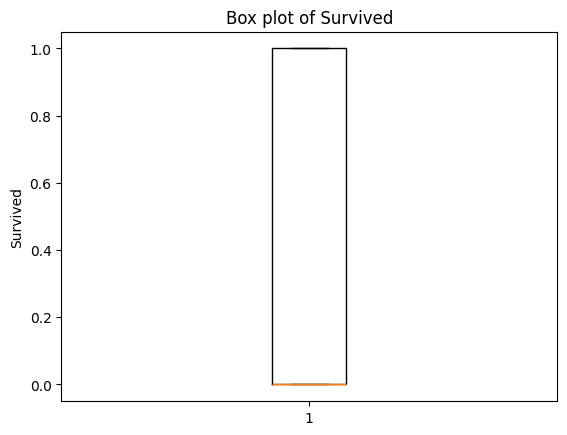

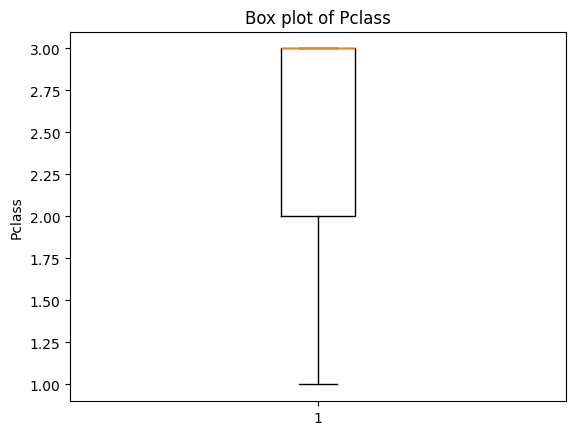

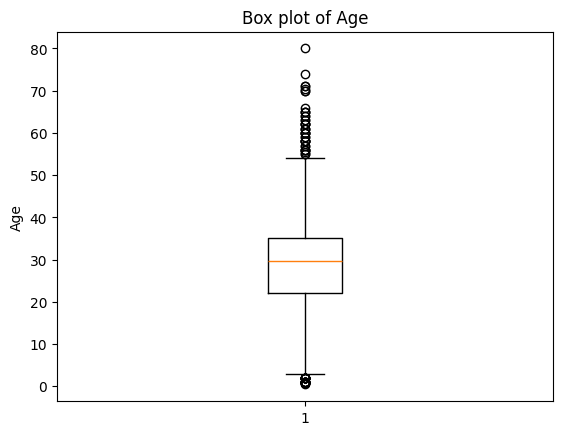

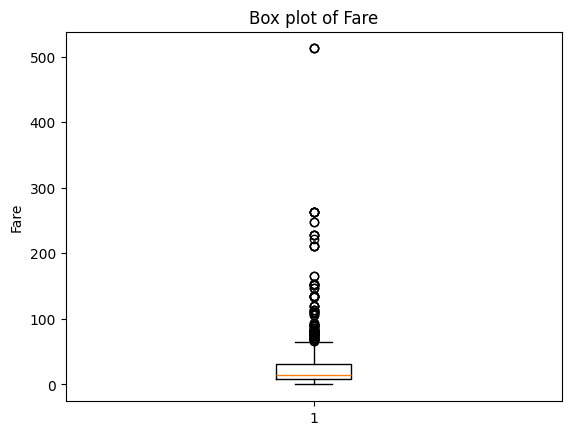

In [338]:
column_s = ['Survived','Pclass','Age','Fare']

for col in column_s:
    plt.figure()
    plt.boxplot(new[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
    plt.show()

In [339]:
Q1 = new['Age'].quantile(0.25)
Q3 = new['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
new['Age'] = np.where(new['Age'] < lower_bound, new['Age'].mean(),new['Age'])
new['Age'] = np.where(new['Age'] > upper_bound, new['Age'].mean(),new['Age'])



Q1 = new['Fare'].quantile(0.25)
Q3 = new['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
new['Fare'] = np.where(new['Fare'] < lower_bound, new['Fare'].mean(),new['Fare'])
new['Fare'] = np.where(new['Fare'] > upper_bound, new['Fare'].mean(),new['Fare'])


Q1 = new['Pclass'].quantile(0.25)
Q3 = new['Pclass'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
new['Pclass'] = np.where(new['Pclass'] < lower_bound, new['Pclass'].mean(),new['Pclass'])
new['Pclass'] = np.where(new['Pclass'] > upper_bound, new['Pclass'].mean(),new['Pclass'])


Q1 = new['Survived'].quantile(0.25)
Q3 = new['Survived'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
new['Survived'] = np.where(new['Survived'] < lower_bound, new['Survived'].mean(),new['Survived'])
new['Survived'] = np.where(new['Survived'] > upper_bound, new['Survived'].mean(),new['Survived'])


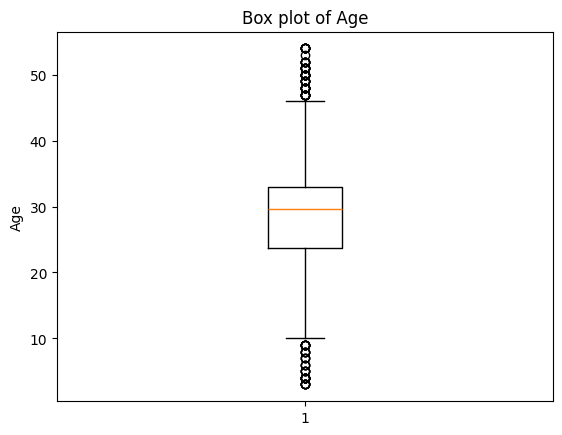

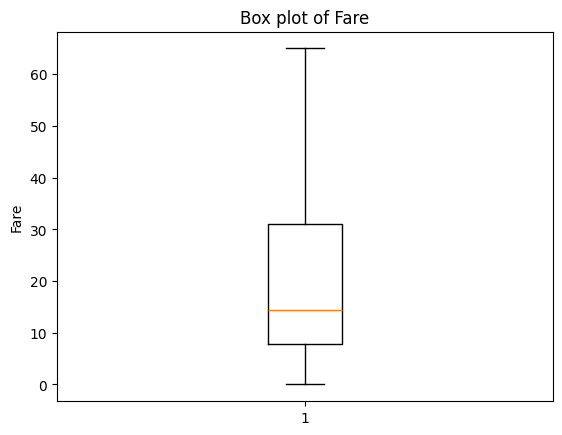

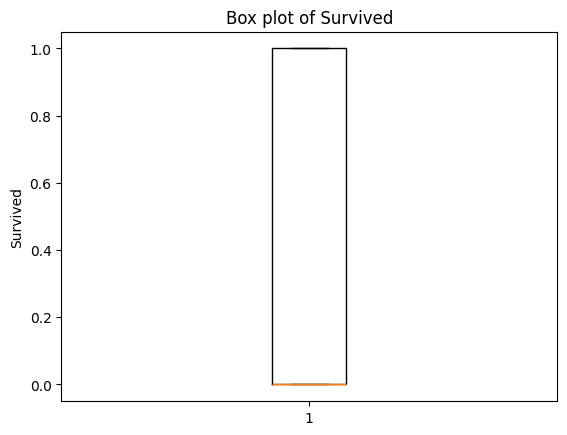

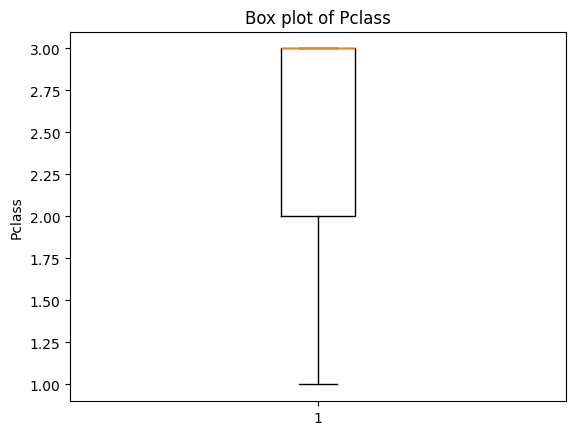

In [340]:
column_s = ['Age','Fare','Survived','Pclass']

for col in column_s:
    plt.figure()
    plt.boxplot(new[col])
    plt.title(f'Box plot of {col}')
    plt.ylabel(col)
    plt.show()

In [341]:
new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    float64
 1   Pclass    891 non-null    float64
 2   Age       891 non-null    float64
 3   Fare      891 non-null    float64
 4   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(4)
memory usage: 28.8 KB


### **Data Normalisation: -**

In [342]:
new.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0.0,3.0,22.0,7.250000,True
1,1.0,1.0,38.0,32.204208,False
2,1.0,3.0,26.0,7.925000,False
3,1.0,1.0,35.0,53.100000,False
4,0.0,3.0,35.0,8.050000,True


In [343]:
new['Survived'] = new["Survived"].astype(int)
new['Pclass'] = new['Pclass'].astype(int)
new['Age'] = new['Age'].astype(int)
new.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0,3,22,7.250000,True
1,1,1,38,32.204208,False
2,1,3,26,7.925000,False
3,1,1,35,53.100000,False
4,0,3,35,8.050000,True


In [344]:
from sklearn.preprocessing import StandardScaler
colm = ['Fare']
scale = StandardScaler()

In [345]:
new[colm] = scale.fit_transform(new[colm])
new.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0,3,-0.693641,-0.918474,True
1,1,1,0.941370,0.923286,False
2,1,3,-0.284888,-0.868656,False
3,1,1,0.634806,2.465512,False
4,0,3,0.634806,-0.859430,True


### **Apply Model: -**

In [346]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [347]:
new.head()

,Survived,Pclass,Age,Fare,Sex_male
0,0,3,-0.693641,-0.918474,True
1,1,1,0.941370,0.923286,False
2,1,3,-0.284888,-0.868656,False
3,1,1,0.634806,2.465512,False
4,0,3,0.634806,-0.859430,True


In [348]:
X = new.drop('Survived',axis = 'columns')
Y = new['Survived']

In [349]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.3,random_state = 42)

In [350]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [351]:
y_pred = model.predict(x_test)

In [352]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred.round())
accuracy

0.753731343283582